# **1. Perkenalan Dataset**


## Deskripsi Dataset

Dataset yang digunakan pada proyek ini adalah **Gold Price Dataset** yang berisi harga emas harian dalam berbagai mata uang.

**Sumber Dataset:** Kaggle / Data primer harga emas LBMA (London Bullion Market Association)

**Informasi Dataset:**
- **Nama:** gold_raw.csv
- **Jumlah Baris:** ±6000 baris (data harian hari kerja)
- **Rentang Waktu:** 2001 - 2023
- **Target Prediksi:** `USD (PM)` — Harga penutupan emas dalam USD

**Kolom Dataset:**
| Kolom | Tipe | Deskripsi |
|-------|------|----------|
| Date | object | Tanggal perdagangan |
| USD (AM) | float | Harga pembukaan emas dalam USD |
| USD (PM) | float | Harga penutupan emas dalam USD (**target**) |
| GBP (AM) | float | Harga pembukaan emas dalam GBP |
| GBP (PM) | float | Harga penutupan emas dalam GBP |
| EURO (AM) | float | Harga pembukaan emas dalam Euro |
| EURO (PM) | float | Harga penutupan emas dalam Euro |

**Tujuan:** Membangun model machine learning untuk memprediksi harga penutupan emas (USD PM) berdasarkan fitur-fitur harga di berbagai mata uang.

# **2. Import Library**

Pada tahap ini, kita mengimpor seluruh pustaka Python yang dibutuhkan untuk analisis data, visualisasi, dan pembangunan model machine learning.

In [ ]:
!%pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Utilities
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Semua library berhasil diimport!')
print(f'Pandas version  : {pd.__version__}')
print(f'NumPy version   : {np.__version__}')

✅ Semua library berhasil diimport!
Pandas version  : 3.0.1
NumPy version   : 2.4.3


# **3. Memuat Dataset**

Pada tahap ini, kita memuat dataset `gold_raw.csv` ke dalam notebook menggunakan pandas, kemudian memeriksa struktur awal data untuk memahami formatnya.

In [7]:
# Load dataset
df = pd.read_csv('../dataset/gold_raw.csv')

print('=' * 50)
print('📊 INFORMASI DASAR DATASET')
print('=' * 50)
print(f'Jumlah baris    : {df.shape[0]:,}')
print(f'Jumlah kolom    : {df.shape[1]}')
print(f'Kolom           : {list(df.columns)}')
print()
print('5 Baris Pertama:')
df.head()

📊 INFORMASI DASAR DATASET
Jumlah baris    : 4,718
Jumlah kolom    : 7
Kolom           : ['Date', 'USD (AM)', 'USD (PM)', 'GBP (AM)', 'GBP (PM)', 'EURO (AM)', 'EURO (PM)']

5 Baris Pertama:


,Date,USD (AM),USD (PM),GBP (AM),GBP (PM),EURO (AM),EURO (PM)
0,2001-01-02,272.80,271.10,183.026,181.617,288.677,287.334
1,2001-01-03,269.00,267.15,178.916,177.390,281.823,281.655
2,2001-01-04,268.75,267.10,178.869,178.352,282.538,282.049
3,2001-01-05,268.00,267.40,178.488,178.148,280.775,280.882
4,2001-01-08,268.60,268.30,178.769,178.664,282.410,282.481


In [8]:
# Info tipe data
print('📋 INFORMASI TIPE DATA')
print('=' * 50)
df.info()

📋 INFORMASI TIPE DATA
<class 'pandas.DataFrame'>
RangeIndex: 4718 entries, 0 to 4717
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       4718 non-null   str    
 1   USD (AM)   4718 non-null   float64
 2   USD (PM)   4682 non-null   float64
 3   GBP (AM)   4718 non-null   float64
 4   GBP (PM)   4682 non-null   float64
 5   EURO (AM)  4718 non-null   float64
 6   EURO (PM)  4682 non-null   float64
dtypes: float64(6), str(1)
memory usage: 258.1 KB


In [9]:
# Statistik deskriptif
print('📈 STATISTIK DESKRIPTIF')
print('=' * 50)
df.describe().round(2)

📈 STATISTIK DESKRIPTIF


,USD (AM),USD (PM),GBP (AM),GBP (PM),EURO (AM),EURO (PM)
count,4718.00,4682.00,4718.00,4682.00,4718.00,4682.00
mean,959.99,959.73,625.07,624.92,773.89,773.84
std,449.46,449.49,324.49,324.54,351.56,351.70
min,256.70,255.95,176.57,176.44,276.71,277.67
25%,449.11,448.61,244.58,244.46,361.39,361.34
50%,1113.12,1112.28,717.14,716.21,874.35,875.14
75%,1293.75,1294.22,939.07,939.27,1085.97,1085.82
max,1896.50,1895.00,1265.90,1265.01,1389.89,1392.03


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, kita melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik, distribusi, dan hubungan antar variabel dalam dataset harga emas.

❓ MISSING VALUES
           Count  Percentage (%)
Date           0            0.00
USD (AM)       0            0.00
USD (PM)      36            0.76
GBP (AM)       0            0.00
GBP (PM)      36            0.76
EURO (AM)      0            0.00
EURO (PM)     36            0.76


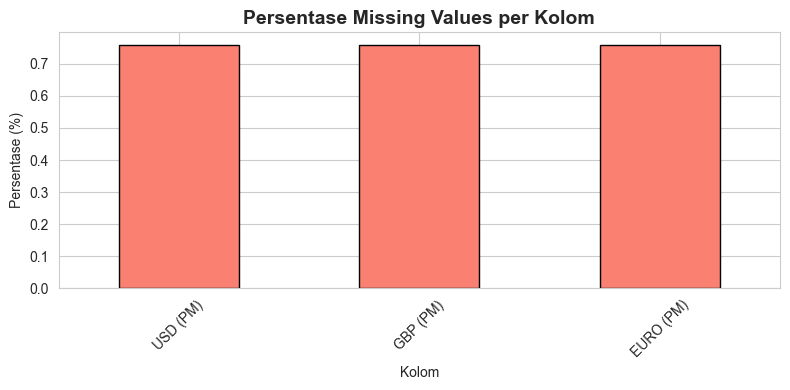

✅ Visualisasi missing values disimpan.


In [ ]:
# 4.1 Cek Missing Values
print('❓ MISSING VALUES')
print('=' * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df)

# Visualisasi missing values
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct[missing_pct > 0].plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
ax.set_title('Persentase Missing Values per Kolom', fontsize=14, fontweight='bold')
ax.set_ylabel('Persentase (%)')
ax.set_xlabel('Kolom')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_missing_values.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Visualisasi missing values disimpan.')

📊 DISTRIBUSI DATA


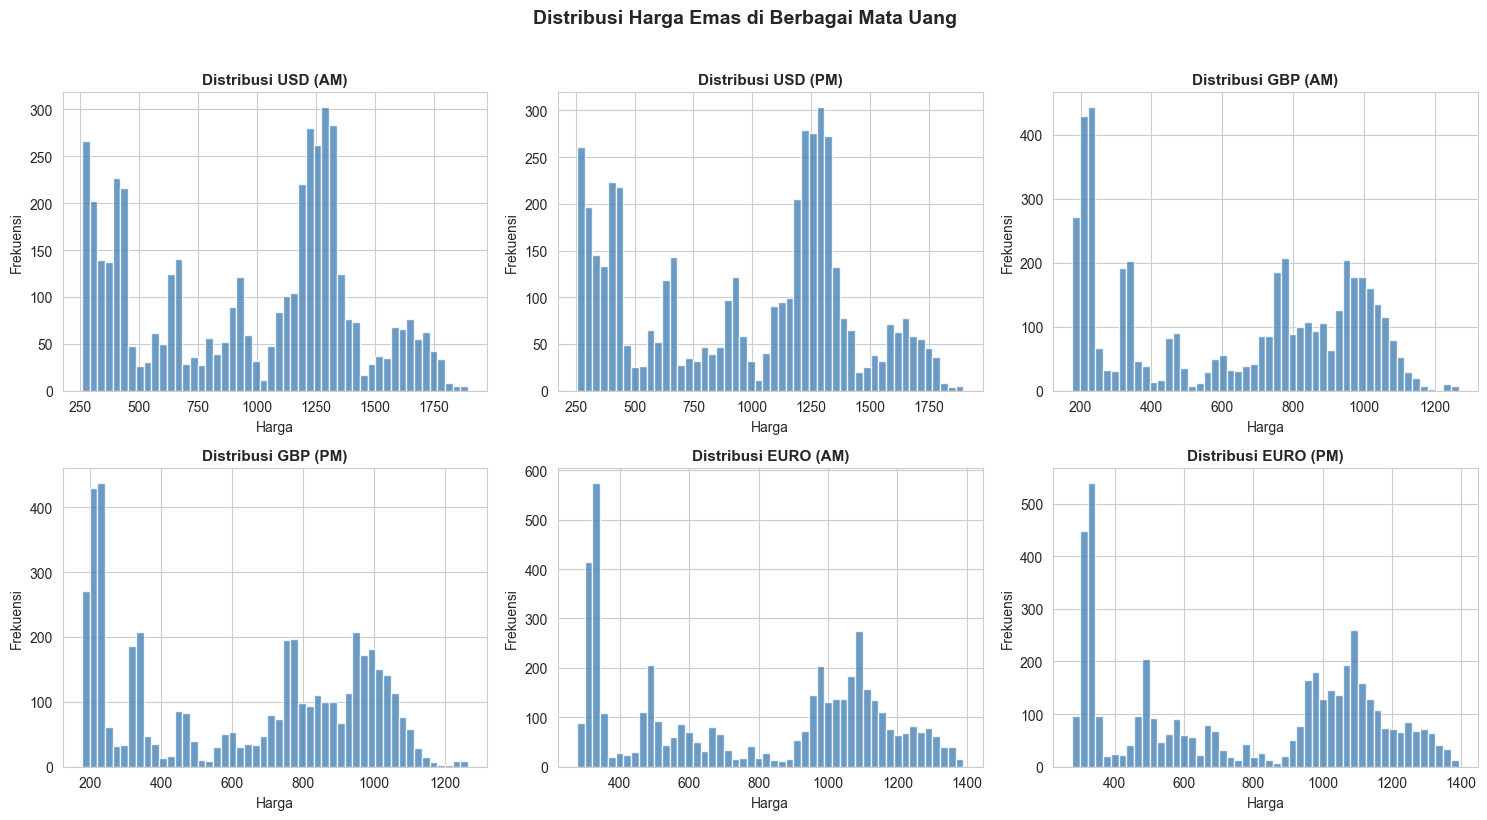

✅ Visualisasi distribusi disimpan.


In [12]:
# 4.2 Distribusi Data (Histogram)
print('📊 DISTRIBUSI DATA')
print('=' * 50)

numeric_cols = ['USD (AM)', 'USD (PM)', 'GBP (AM)', 'GBP (PM)', 'EURO (AM)', 'EURO (PM)']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'Distribusi {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Harga')
    axes[i].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Harga Emas di Berbagai Mata Uang', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_distribusi.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Visualisasi distribusi disimpan.')

📈 TREND HARGA EMAS


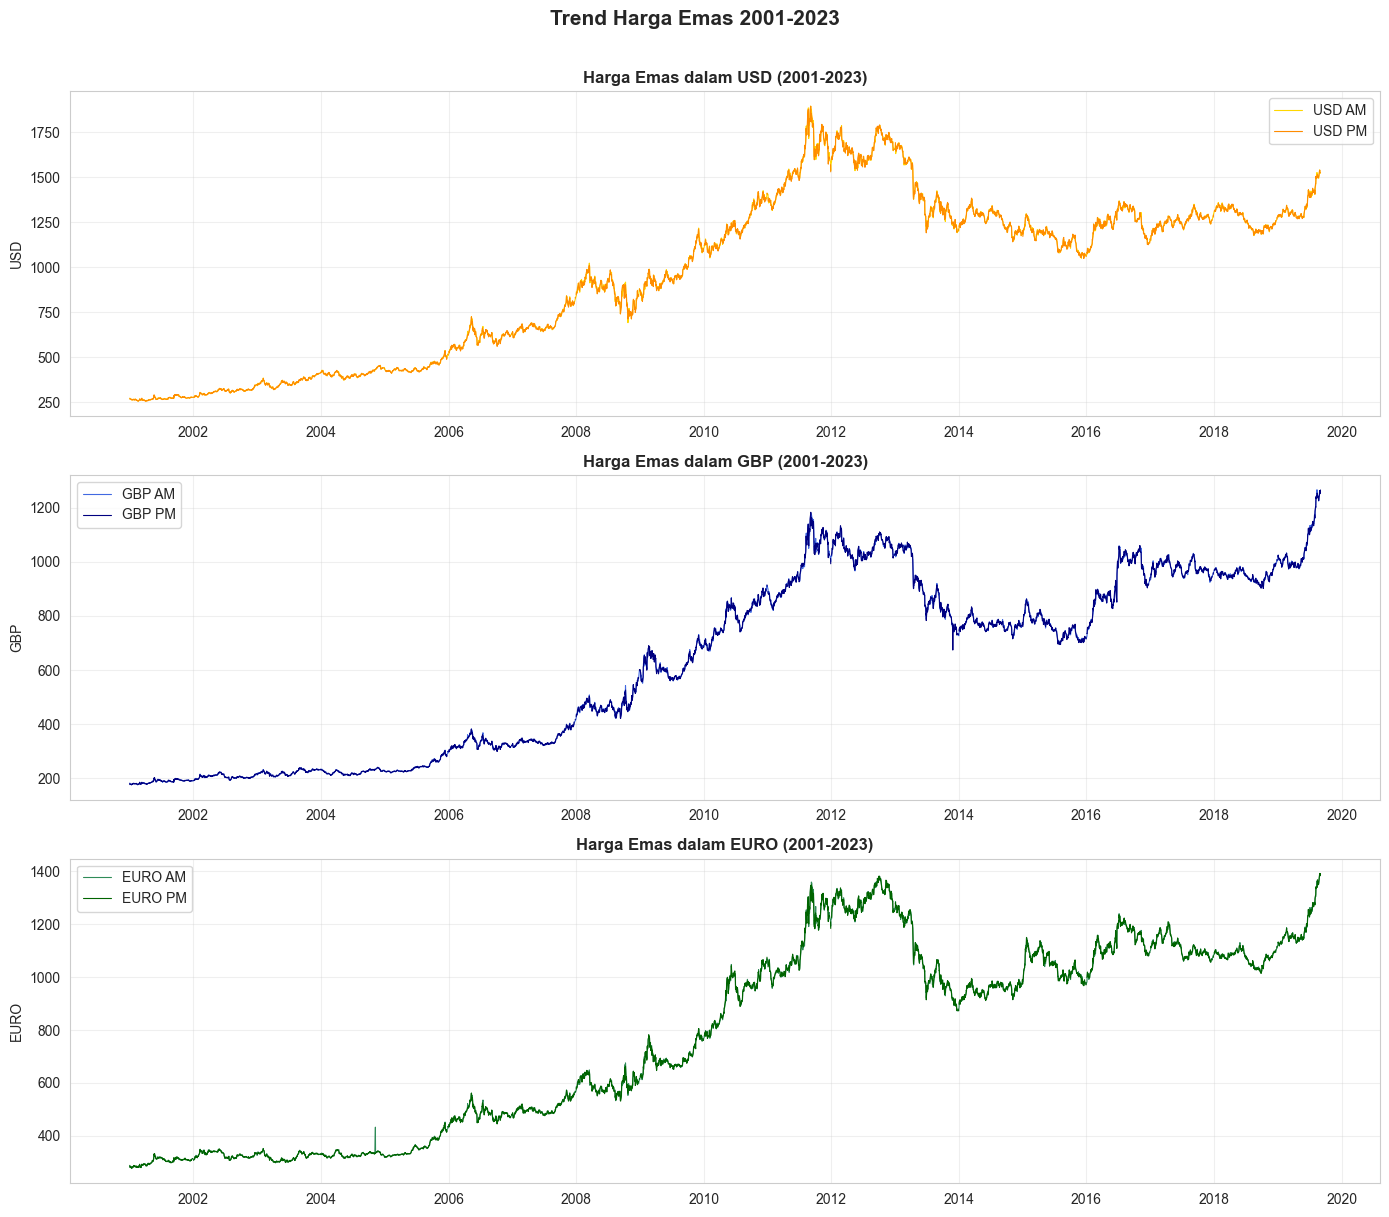

✅ Visualisasi trend disimpan.


In [13]:
# 4.3 Trend Harga Emas dari Waktu ke Waktu
print('📈 TREND HARGA EMAS')
print('=' * 50)

df['Date'] = pd.to_datetime(df['Date'])

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# USD
axes[0].plot(df['Date'], df['USD (AM)'], label='USD AM', color='gold', linewidth=0.8)
axes[0].plot(df['Date'], df['USD (PM)'], label='USD PM', color='darkorange', linewidth=0.8)
axes[0].set_title('Harga Emas dalam USD (2001-2023)', fontweight='bold')
axes[0].set_ylabel('USD')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# GBP
axes[1].plot(df['Date'], df['GBP (AM)'], label='GBP AM', color='royalblue', linewidth=0.8)
axes[1].plot(df['Date'], df['GBP (PM)'], label='GBP PM', color='navy', linewidth=0.8)
axes[1].set_title('Harga Emas dalam GBP (2001-2023)', fontweight='bold')
axes[1].set_ylabel('GBP')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# EURO
axes[2].plot(df['Date'], df['EURO (AM)'], label='EURO AM', color='seagreen', linewidth=0.8)
axes[2].plot(df['Date'], df['EURO (PM)'], label='EURO PM', color='darkgreen', linewidth=0.8)
axes[2].set_title('Harga Emas dalam EURO (2001-2023)', fontweight='bold')
axes[2].set_ylabel('EURO')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Trend Harga Emas 2001-2023', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_trend.png', dpi=100, bbox_inches='tight')
plt.show()
print('✅ Visualisasi trend disimpan.')

🔗 MATRIKS KORELASI


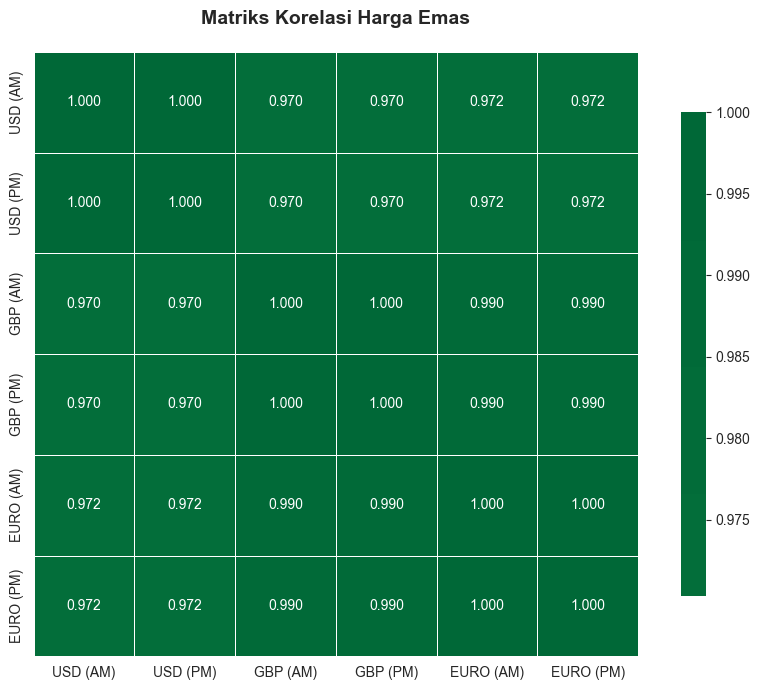


Korelasi dengan Target (USD PM):
USD (PM)     1.000000
USD (AM)     0.999892
EURO (PM)    0.971826
EURO (AM)    0.971739
GBP (PM)     0.970444
GBP (AM)     0.970400
Name: USD (PM), dtype: float64


In [14]:
# 4.4 Heatmap Korelasi
print('🔗 MATRIKS KORELASI')
print('=' * 50)

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matriks Korelasi Harga Emas', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('eda_korelasi.png', dpi=100, bbox_inches='tight')
plt.show()

print('\nKorelasi dengan Target (USD PM):')
print(corr_matrix['USD (PM)'].sort_values(ascending=False))

📦 BOXPLOT & OUTLIER DETECTION


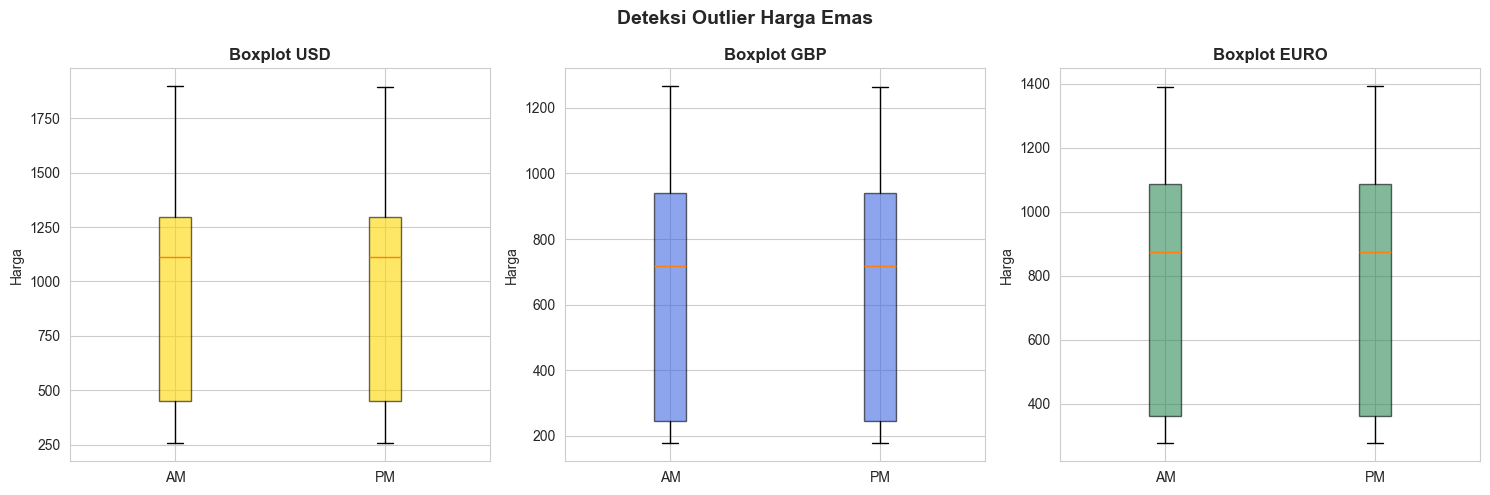


📊 Jumlah Outlier (IQR Method):
  USD (AM): 0 outlier
  USD (PM): 0 outlier
  GBP (AM): 0 outlier
  GBP (PM): 0 outlier
  EURO (AM): 0 outlier
  EURO (PM): 0 outlier


In [15]:
# 4.5 Boxplot - Deteksi Outlier
print('📦 BOXPLOT & OUTLIER DETECTION')
print('=' * 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

pairs = [('USD (AM)', 'USD (PM)'), ('GBP (AM)', 'GBP (PM)'), ('EURO (AM)', 'EURO (PM)')]
colors = ['gold', 'royalblue', 'seagreen']

for i, (col_am, col_pm) in enumerate(pairs):
    data = df[[col_am, col_pm]].dropna()
    axes[i].boxplot([data[col_am], data[col_pm]], labels=['AM', 'PM'], patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.6))
    currency = col_am.split(' ')[0]
    axes[i].set_title(f'Boxplot {currency}', fontweight='bold')
    axes[i].set_ylabel('Harga')

plt.suptitle('Deteksi Outlier Harga Emas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=100, bbox_inches='tight')
plt.show()

# Hitung outlier menggunakan IQR
print('\n📊 Jumlah Outlier (IQR Method):')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)][col].count()
    print(f'  {col}: {outliers} outlier')

📉 ANALISIS RETURN HARIAN USD


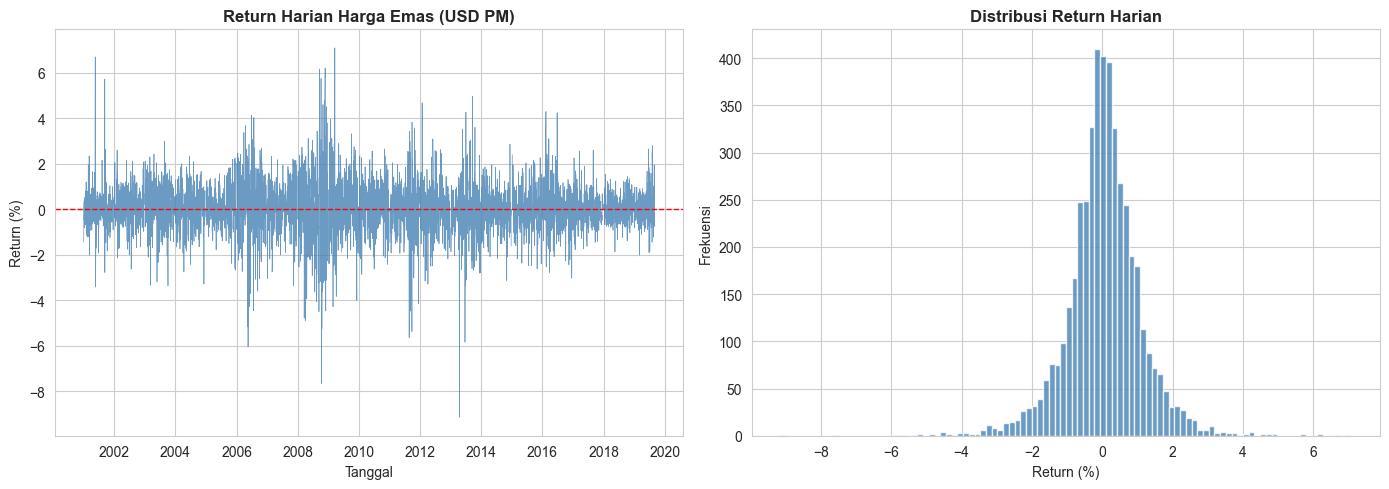


Statistik Return Harian:
count    4645.0000
mean        0.0353
std         1.0921
min        -9.1501
25%        -0.5013
50%         0.0374
75%         0.6015
max         7.0809
Name: daily_return, dtype: float64


In [17]:
# 4.6 Analisis Return Harian
print('📉 ANALISIS RETURN HARIAN USD')
print('=' * 50)

df_sorted = df.sort_values('Date').copy()
df_sorted['daily_return'] = df_sorted['USD (PM)'].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot return
axes[0].plot(df_sorted['Date'], df_sorted['daily_return'], color='steelblue', linewidth=0.5, alpha=0.8)
axes[0].axhline(0, color='red', linewidth=1, linestyle='--')
axes[0].set_title('Return Harian Harga Emas (USD PM)', fontweight='bold')
axes[0].set_ylabel('Return (%)')
axes[0].set_xlabel('Tanggal')

# Distribusi return
axes[1].hist(df_sorted['daily_return'].dropna(), bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].set_title('Distribusi Return Harian', fontweight='bold')
axes[1].set_xlabel('Return (%)')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_return.png', dpi=100, bbox_inches='tight')
plt.show()

print(f'\nStatistik Return Harian:')
print(df_sorted['daily_return'].describe().round(4))

### Ringkasan EDA

Dari eksplorasi data di atas, diperoleh insight sebagai berikut:

1. **Trend:** Harga emas menunjukkan tren naik yang signifikan dari ~$270 (2001) ke ~$2000+ (2023).
2. **Korelasi:** Seluruh fitur numerik memiliki korelasi yang sangat tinggi (>0.99) satu sama lain, terutama AM vs PM dalam mata uang yang sama.
3. **Missing Values:** Terdapat missing values pada kolom GBP dan EURO (~1%), perlu ditangani dengan imputasi.
4. **Outlier:** Tidak ada outlier ekstrem — pergerakan harga mengikuti distribusi mendekati normal.
5. **Return Harian:** Return harian terdistribusi normal dengan rata-rata mendekati 0, sesekali ada lonjakan ekstrem.

# **5. Data Preprocessing**

Pada tahap ini, kita melakukan preprocessing data untuk mempersiapkan data agar siap dilatih oleh model machine learning. Tahapan yang dilakukan:

1. Menghapus kolom `Date` (tidak digunakan sebagai fitur langsung)
2. Menangani Missing Values dengan median imputation
3. Feature Engineering (tambah fitur turunan)
4. Normalisasi Fitur dengan MinMaxScaler
5. Split Train-Test
6. Simpan hasil preprocessing

In [18]:
# 5.1 Persiapan Data
print('🔧 TAHAP 1: Persiapan Data')
print('=' * 50)

df_prep = df.copy()

# Konversi Date ke datetime
df_prep['Date'] = pd.to_datetime(df_prep['Date'])
df_prep = df_prep.sort_values('Date').reset_index(drop=True)

print(f'Shape awal       : {df_prep.shape}')
print(f'Rentang tanggal  : {df_prep["Date"].min()} s/d {df_prep["Date"].max()}')

🔧 TAHAP 1: Persiapan Data
Shape awal       : (4718, 7)
Rentang tanggal  : 2001-01-02 00:00:00 s/d 2019-09-02 00:00:00


In [19]:
# 5.2 Menangani Missing Values
print('🔧 TAHAP 2: Menangani Missing Values')
print('=' * 50)

print(f'Missing values sebelum imputasi:')
print(df_prep.isnull().sum())

# Imputasi dengan median
numeric_cols_prep = ['USD (AM)', 'USD (PM)', 'GBP (AM)', 'GBP (PM)', 'EURO (AM)', 'EURO (PM)']
imputer = SimpleImputer(strategy='median')
df_prep[numeric_cols_prep] = imputer.fit_transform(df_prep[numeric_cols_prep])

print(f'\nMissing values setelah imputasi:')
print(df_prep.isnull().sum())
print('\n✅ Missing values berhasil ditangani!')

🔧 TAHAP 2: Menangani Missing Values
Missing values sebelum imputasi:
Date          0
USD (AM)      0
USD (PM)     36
GBP (AM)      0
GBP (PM)     36
EURO (AM)     0
EURO (PM)    36
dtype: int64

Missing values setelah imputasi:
Date         0
USD (AM)     0
USD (PM)     0
GBP (AM)     0
GBP (PM)     0
EURO (AM)    0
EURO (PM)    0
dtype: int64

✅ Missing values berhasil ditangani!


In [20]:
# 5.3 Menghapus Duplikasi
print('🔧 TAHAP 3: Menghapus Data Duplikat')
print('=' * 50)

n_before = len(df_prep)
df_prep = df_prep.drop_duplicates(subset=['Date'])
n_after = len(df_prep)

print(f'Baris sebelum    : {n_before:,}')
print(f'Baris setelah    : {n_after:,}')
print(f'Duplikat dihapus : {n_before - n_after}')

🔧 TAHAP 3: Menghapus Data Duplikat
Baris sebelum    : 4,718
Baris setelah    : 4,718
Duplikat dihapus : 0


In [21]:
# 5.4 Feature Engineering
print('🔧 TAHAP 4: Feature Engineering')
print('=' * 50)

# Fitur spread AM-PM
df_prep['USD_spread'] = df_prep['USD (PM)'] - df_prep['USD (AM)']
df_prep['GBP_spread'] = df_prep['GBP (PM)'] - df_prep['GBP (AM)']
df_prep['EURO_spread'] = df_prep['EURO (PM)'] - df_prep['EURO (AM)']

# Moving Average 7 dan 30 hari
df_prep['USD_MA7']  = df_prep['USD (PM)'].rolling(window=7, min_periods=1).mean()
df_prep['USD_MA30'] = df_prep['USD (PM)'].rolling(window=30, min_periods=1).mean()

# Volatilitas (std 7 hari)
df_prep['USD_volatility'] = df_prep['USD (PM)'].rolling(window=7, min_periods=1).std().fillna(0)

# Fitur waktu
df_prep['year']  = df_prep['Date'].dt.year
df_prep['month'] = df_prep['Date'].dt.month
df_prep['dow']   = df_prep['Date'].dt.dayofweek  # 0=Senin, 4=Jumat

print(f'Fitur baru yang ditambahkan:')
new_features = ['USD_spread', 'GBP_spread', 'EURO_spread', 'USD_MA7', 'USD_MA30', 'USD_volatility', 'year', 'month', 'dow']
for f in new_features:
    print(f'  ✅ {f}')

print(f'\nShape setelah feature engineering: {df_prep.shape}')

🔧 TAHAP 4: Feature Engineering
Fitur baru yang ditambahkan:
  ✅ USD_spread
  ✅ GBP_spread
  ✅ EURO_spread
  ✅ USD_MA7
  ✅ USD_MA30
  ✅ USD_volatility
  ✅ year
  ✅ month
  ✅ dow

Shape setelah feature engineering: (4718, 16)


In [22]:
# 5.5 Penanganan Outlier (Clipping IQR)
print('🔧 TAHAP 5: Penanganan Outlier')
print('=' * 50)

# Untuk harga emas, outlier bisa jadi informasi penting (peak harga)
# Kita hanya clip spread yang ekstrem
for col in ['USD_spread', 'GBP_spread', 'EURO_spread']:
    Q1 = df_prep[col].quantile(0.01)
    Q3 = df_prep[col].quantile(0.99)
    before = df_prep[(df_prep[col] < Q1) | (df_prep[col] > Q3)][col].count()
    df_prep[col] = df_prep[col].clip(lower=Q1, upper=Q3)
    print(f'  {col}: {before} nilai di-clip ke [{Q1:.3f}, {Q3:.3f}]')

print('\n✅ Penanganan outlier selesai!')

🔧 TAHAP 5: Penanganan Outlier
  USD_spread: 96 nilai di-clip ke [-23.124, 19.790]
  GBP_spread: 96 nilai di-clip ke [-14.528, 12.778]
  EURO_spread: 96 nilai di-clip ke [-16.779, 15.353]

✅ Penanganan outlier selesai!


In [23]:
# 5.6 Normalisasi / Standarisasi Fitur
print('🔧 TAHAP 6: Normalisasi Fitur (MinMaxScaler)')
print('=' * 50)

# Tentukan fitur dan target
feature_cols = [
    'USD (AM)', 'GBP (AM)', 'GBP (PM)', 'EURO (AM)', 'EURO (PM)',
    'USD_spread', 'GBP_spread', 'EURO_spread',
    'USD_MA7', 'USD_MA30', 'USD_volatility',
    'year', 'month', 'dow'
]
target_col = 'USD (PM)'

X = df_prep[feature_cols].copy()
y = df_prep[target_col].copy()

# Normalisasi fitur numerik (bukan time features)
scale_cols = [
    'USD (AM)', 'GBP (AM)', 'GBP (PM)', 'EURO (AM)', 'EURO (PM)',
    'USD_spread', 'GBP_spread', 'EURO_spread',
    'USD_MA7', 'USD_MA30', 'USD_volatility'
]

scaler = MinMaxScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

print(f'Fitur input  : {len(feature_cols)} fitur')
print(f'Target       : {target_col}')
print(f'\nContoh data setelah normalisasi:')
print(X.head(3).round(4))

🔧 TAHAP 6: Normalisasi Fitur (MinMaxScaler)
Fitur input  : 14 fitur
Target       : USD (PM)

Contoh data setelah normalisasi:
   USD (AM)  GBP (AM)  GBP (PM)  EURO (AM)  EURO (PM)  USD_spread  GBP_spread  \
0    0.0098    0.0059    0.0048     0.0107     0.0087      0.4992      0.4804   
1    0.0075    0.0022    0.0009     0.0046     0.0036      0.4957      0.4762   
2    0.0073    0.0021    0.0018     0.0052     0.0039      0.5004      0.5131   

   EURO_spread  USD_MA7  USD_MA30  USD_volatility  year  month  dow  
0       0.4804   0.0083    0.0068          0.0000  2001      1    1  
1       0.5170   0.0070    0.0055          0.0069  2001      1    2  
2       0.5070   0.0066    0.0051          0.0056  2001      1    3  


In [24]:
# 5.7 Split Train-Test
print('🔧 TAHAP 7: Split Data Train-Test')
print('=' * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False  # shuffle=False untuk time series
)

print(f'Total data   : {len(X):,}')
print(f'Train set    : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test set     : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)')

🔧 TAHAP 7: Split Data Train-Test
Total data   : 4,718
Train set    : 3,774 (80%)
Test set     : 944  (20%)


In [25]:
# 5.8 Simpan Data Preprocessing
print('🔧 TAHAP 8: Menyimpan Data Preprocessing')
print('=' * 50)

# Buat folder output
os.makedirs('gold_preprocessing', exist_ok=True)

# Gabungkan fitur + target untuk disimpan
train_df = X_train.copy()
train_df[target_col] = y_train

test_df = X_test.copy()
test_df[target_col] = y_test

# Simpan
train_df.to_csv('gold_preprocessing/gold_train.csv', index=False)
test_df.to_csv('gold_preprocessing/gold_test.csv', index=False)

# Simpan juga full preprocessed
full_df = X.copy()
full_df[target_col] = y
full_df.to_csv('gold_preprocessing/gold_full_preprocessed.csv', index=False)

print(f'✅ Dataset training disimpan    : gold_preprocessing/gold_train.csv')
print(f'✅ Dataset testing disimpan     : gold_preprocessing/gold_test.csv')
print(f'✅ Dataset full disimpan        : gold_preprocessing/gold_full_preprocessed.csv')
print(f'\nShape train : {train_df.shape}')
print(f'Shape test  : {test_df.shape}')
print(f'\n{train_df.head(3)}')

🔧 TAHAP 8: Menyimpan Data Preprocessing
✅ Dataset training disimpan    : gold_preprocessing/gold_train.csv
✅ Dataset testing disimpan     : gold_preprocessing/gold_test.csv
✅ Dataset full disimpan        : gold_preprocessing/gold_full_preprocessed.csv

Shape train : (3774, 15)
Shape test  : (944, 15)

   USD (AM)  GBP (AM)  GBP (PM)  EURO (AM)  EURO (PM)  USD_spread  GBP_spread  \
0  0.009818  0.005925  0.004755   0.010749   0.008675    0.499231    0.480446   
1  0.007501  0.002152  0.000872   0.004592   0.003579    0.495736    0.476161   
2  0.007348  0.002109  0.001756   0.005235   0.003932    0.500396    0.513113   

   EURO_spread   USD_MA7  USD_MA30  USD_volatility  year  month  dow  USD (PM)  
0     0.480403  0.008265  0.006762        0.000000  2001      1    1    271.10  
1     0.516971  0.007032  0.005489        0.006855  2001      1    2    267.15  
2     0.506981  0.006610  0.005054        0.005633  2001      1    3    267.10  
